In [1]:
import os
import re
import cv2
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import kagglehub

plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["image.cmap"] = "gray"

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DOWNLOAD_DIR = Path(
    kagglehub.dataset_download("nizier193/leaf-segmentation-dataset-mk7")
)

print("Downloaded to:", DOWNLOAD_DIR)

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/simple_segmentation_training")
DRIVE_PROJECT_DIR.mkdir(parents=True, exist_ok=True)

DATASET_DIR = DRIVE_PROJECT_DIR / "dataset"

if not DATASET_DIR.exists():
    shutil.copytree(DOWNLOAD_DIR, DATASET_DIR)
    print("Copied dataset to Drive:", DATASET_DIR)
else:
    print("Dataset already exists in Drive:", DATASET_DIR)

Using Colab cache for faster access to the 'leaf-segmentation-dataset-mk7' dataset.
Downloaded to: /kaggle/input/leaf-segmentation-dataset-mk7
Copied dataset to Drive: /content/drive/MyDrive/simple_segmentation_training/dataset


In [4]:
for root, dirs, files in os.walk(DATASET_DIR):
    level = root.replace(str(DATASET_DIR), "").count(os.sep)
    indent = " " * 2 * level
    print(f"{indent}{Path(root).name}/")
    for f in files[:3]:
        print(" " * 2 * (level + 1) + f)
    if level >= 2:
        continue

dataset/
  aug/
    images/
      image-332-0.jpg
      image-79-0.jpg
      image-70-0.jpg
    masks/
      mask-7-1.jpg
      mask-89-0.jpg
      mask-207-1.jpg


In [5]:
image_exts = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp"}

all_dirs = [p for p in DATASET_DIR.rglob("*") if p.is_dir()]

def count_images(folder):
    return len([p for p in folder.glob("*") if p.suffix.lower() in image_exts])

image_candidates = []
mask_candidates = []

for d in all_dirs:
    name = d.name.lower()
    n_files = count_images(d)
    if n_files == 0:
        continue

    if any(k in name for k in ["image", "images", "img", "rgb"]):
        image_candidates.append((d, n_files))
    if any(k in name for k in ["mask", "masks", "label", "labels", "annotation", "annotations"]):
        mask_candidates.append((d, n_files))

print("Image candidates:")
for d, n in image_candidates[:10]:
    print("-", d, "|", n)

print("\nMask candidates:")
for d, n in mask_candidates[:10]:
    print("-", d, "|", n)

Image candidates:
- /content/drive/MyDrive/simple_segmentation_training/dataset/aug/images | 552

Mask candidates:
- /content/drive/MyDrive/simple_segmentation_training/dataset/aug/masks | 552


In [6]:

IMAGE_DIR = sorted(image_candidates, key=lambda x: x[1], reverse=True)[0][0]
MASK_DIR = sorted(mask_candidates, key=lambda x: x[1], reverse=True)[0][0]

print("IMAGE_DIR:", IMAGE_DIR)
print("MASK_DIR :", MASK_DIR)

IMAGE_DIR: /content/drive/MyDrive/simple_segmentation_training/dataset/aug/images
MASK_DIR : /content/drive/MyDrive/simple_segmentation_training/dataset/aug/masks


In [7]:

def read_image(path, size=(256, 256)):
    img = cv2.imread(str(path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)
    return img

def read_mask(path, size=(256, 256)):
    mask = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    mask = cv2.resize(mask, size)
    _, mask = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    return mask

def show_many(images, titles, cols=3, size=(15, 8)):
    rows = int(np.ceil(len(images) / cols))
    plt.figure(figsize=size)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if len(img.shape) == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)
        plt.title(titles[i])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

def overlay_mask(image, mask, color=(255, 0, 0), alpha=0.35):
    out = image.copy()
    color_layer = np.zeros_like(image)
    color_layer[:, :] = color
    mask_bool = mask > 0
    out[mask_bool] = cv2.addWeighted(image[mask_bool], 1-alpha, color_layer[mask_bool], alpha, 0)
    return out

In [8]:
def list_image_files(folder):
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in image_exts])

def extract_id(name):
    name = Path(name).stem.lower()
    m = re.search(r"(\d+-\d+)$", name)
    if m:
        return m.group(1)

    nums = re.findall(r"\d+", name)
    if len(nums) >= 2:
        return f"{nums[-2]}-{nums[-1]}"
    elif len(nums) == 1:
        return nums[0]
    return name

def build_pairs(image_dir, mask_dir):
    image_files = list_image_files(image_dir)
    mask_files = list_image_files(mask_dir)

    mask_map = {}
    for m in mask_files:
        mask_map[extract_id(m.name)] = m

    pairs = []
    for img_path in image_files:
        key = extract_id(img_path.name)
        if key in mask_map:
            pairs.append((img_path, mask_map[key]))

    return pairs

pairs = build_pairs(IMAGE_DIR, MASK_DIR)

print("Images found:", len(list_image_files(IMAGE_DIR)))
print("Masks found :", len(list_image_files(MASK_DIR)))
print("Pairs found :", len(pairs))

Images found: 552
Masks found : 552
Pairs found : 552


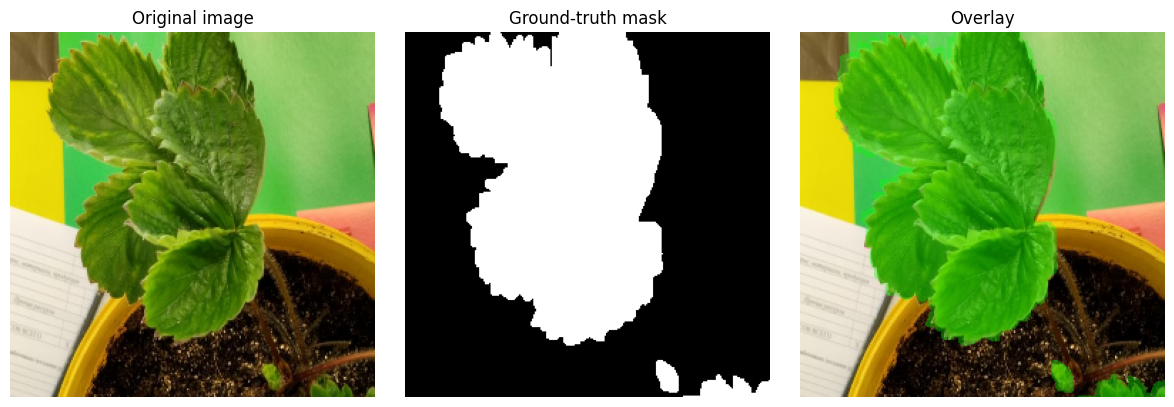

Image: image-0-0.jpg
Mask : mask-0-0.jpg


In [9]:

if len(pairs) == 0:
    raise ValueError("No image-mask pairs found. Check IMAGE_DIR and MASK_DIR.")

img_path, mask_path = pairs[0]

img = read_image(img_path)
gt = read_mask(mask_path)
over = overlay_mask(img, gt, color=(0, 255, 0))

show_many(
    [img, gt, over],
    ["Original image", "Ground-truth mask", "Overlay"],
    cols=3,
    size=(12, 4)
)

print("Image:", img_path.name)
print("Mask :", mask_path.name)

In [18]:
def largest_component(binary):
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(binary, connectivity=8)
    if num_labels <= 1:
        return binary

    areas = stats[1:, cv2.CC_STAT_AREA]
    largest_idx = 1 + np.argmax(areas)

    out = np.zeros_like(binary)
    out[labels == largest_idx] = 255
    return out

def segment_method(image, kernel_size=(5, 5), thresh_type=cv2.THRESH_BINARY_INV, adaptive_thresh_block_size=None):
    gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
    blur = cv2.GaussianBlur(gray, kernel_size, 0)

    if adaptive_thresh_block_size:
        mask = cv2.adaptiveThreshold(
            blur, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            thresh_type, adaptive_thresh_block_size, 2
        )
    else:
        _, mask = cv2.threshold(
            blur, 0, 255,
            thresh_type + cv2.THRESH_OTSU
        )

    kernel = np.ones(kernel_size, np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)

    mask = largest_component(mask)
    return gray, blur, mask

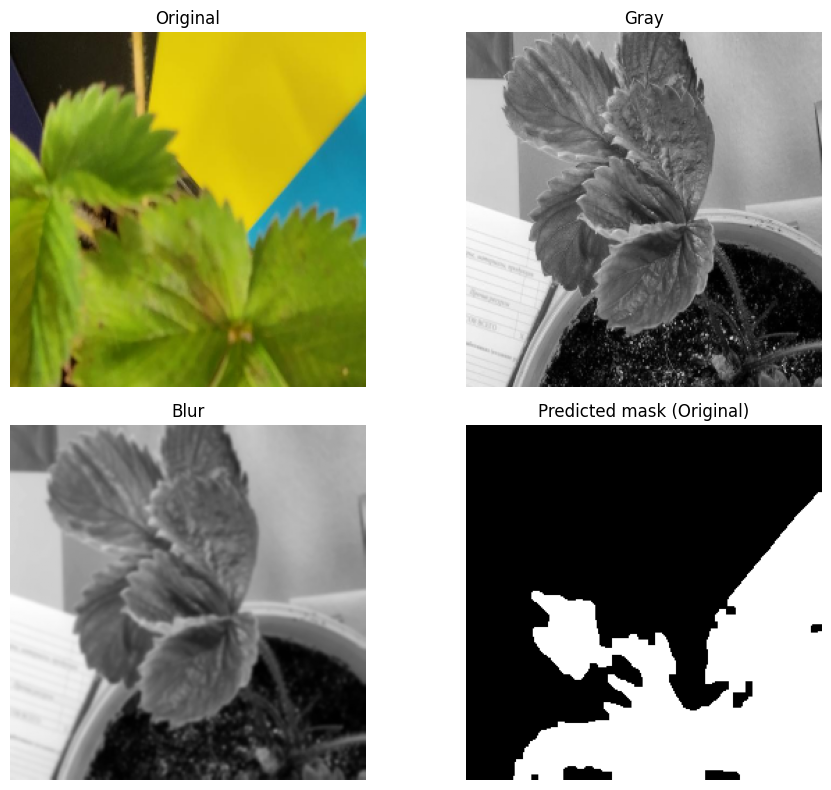

In [19]:

_, _, pred = segment_method(img)

show_many(
    [img, gray, blur, pred],
    ["Original", "Gray", "Blur", "Predicted mask (Original)"],
    cols=2,
    size=(10, 8)
)

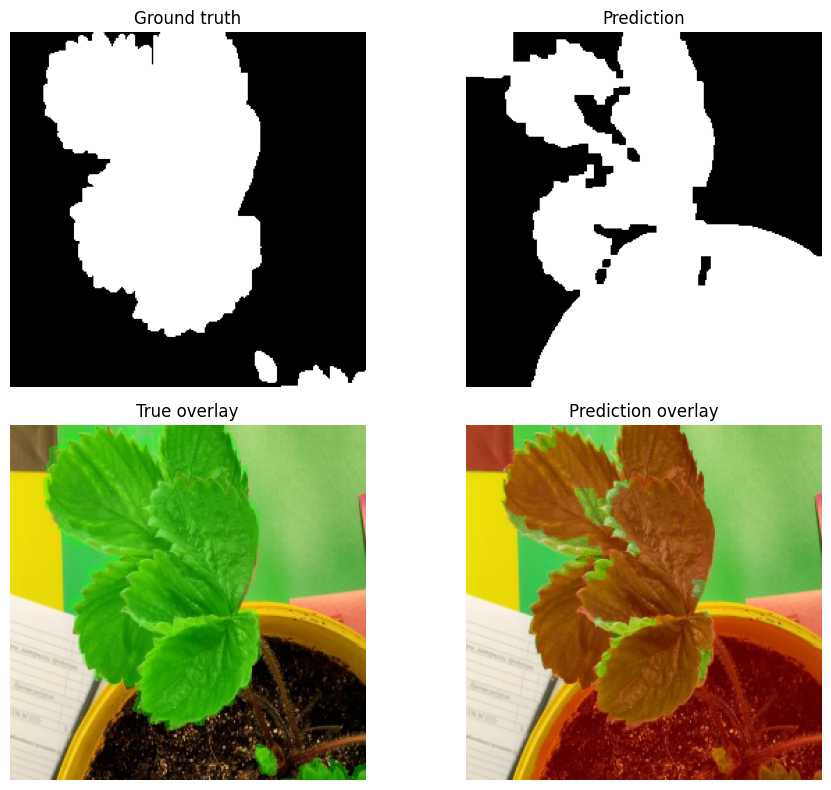

In [12]:

show_many(
    [gt, pred, overlay_mask(img, gt, color=(0, 255, 0)), overlay_mask(img, pred, color=(255, 0, 0))],
    ["Ground truth", "Prediction", "True overlay", "Prediction overlay"],
    cols=2,
    size=(10, 8)
)

In [13]:

def to_binary(mask):
    return (mask > 0).astype(np.uint8)

def segmentation_metrics(y_true, y_pred):
    y_true = to_binary(y_true).flatten()
    y_pred = to_binary(y_pred).flatten()

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn + 1e-8)
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    f1 = 2 * precision * recall / (precision + recall + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)
    dice = 2 * tp / (2 * tp + fp + fn + 1e-8)

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "iou": iou,
        "dice": dice
    }

In [14]:
metrics = segmentation_metrics(gt, pred)

for k, v in metrics.items():
    print(f"{k:10s}: {v:.4f}")

accuracy  : 0.7066
precision : 0.5993
recall    : 0.8383
f1_score  : 0.6990
iou       : 0.5372
dice      : 0.6990


In [20]:

results = []

for i, (img_path, mask_path) in enumerate(pairs[:60]): # Test on 60 images for broader comparison
    img = read_image(img_path)
    gt = read_mask(mask_path)

    # original method (kernel 5x5, THRESH_BINARY_INV + OTSU)
    _, _, pred_orig = segment_method(img, kernel_size=(5, 5), thresh_type=cv2.THRESH_BINARY_INV, adaptive_thresh_block_size=None)
    m_orig = segmentation_metrics(gt, pred_orig)
    row_orig = {"image": img_path.name, "method": "original"}
    row_orig.update(m_orig)
    results.append(row_orig)

    # task 1 kernel size 3 by 3
    _, _, pred_kernel_3x3 = segment_method(img, kernel_size=(3, 3), thresh_type=cv2.THRESH_BINARY_INV, adaptive_thresh_block_size=None)
    m_kernel_3x3 = segmentation_metrics(gt, pred_kernel_3x3)
    row_kernel_3x3 = {"image": img_path.name, "method": "kernel_3x3"}
    row_kernel_3x3.update(m_kernel_3x3)
    results.append(row_kernel_3x3)

    # task 2 THRESH_BINARY instead of THRESH_BINARY_INV
    _, _, pred_binary_thresh = segment_method(img, kernel_size=(5, 5), thresh_type=cv2.THRESH_BINARY, adaptive_thresh_block_size=None)
    m_binary_thresh = segmentation_metrics(gt, pred_binary_thresh)
    row_binary_thresh = {"image": img_path.name, "method": "binary_thresh"}
    row_binary_thresh.update(m_binary_thresh)
    results.append(row_binary_thresh)

    # task 5 adaptive thresholding (using ADAPTIVE_THRESH_GAUSSIAN_C with THRESH_BINARY)
    _, _, pred_adaptive_thresh = segment_method(img, kernel_size=(5, 5), thresh_type=cv2.THRESH_BINARY, adaptive_thresh_block_size=11)
    m_adaptive_thresh = segmentation_metrics(gt, pred_adaptive_thresh)
    row_adaptive_thresh = {"image": img_path.name, "method": "adaptive_thresh"}
    row_adaptive_thresh.update(m_adaptive_thresh)
    results.append(row_adaptive_thresh)

df = pd.DataFrame(results)
display(df.head())

,image,method,accuracy,precision,recall,f1_score,iou,dice
0,image-0-0.jpg,original,0.706558,0.599345,0.838277,0.698956,0.537227,0.698956
1,image-0-0.jpg,kernel_3x3,0.699066,0.593107,0.826412,0.690587,0.527402,0.690587
2,image-0-0.jpg,binary_thresh,0.444672,0.115063,0.054784,0.074227,0.038544,0.074227
3,image-0-0.jpg,adaptive_thresh,0.413254,0.023999,0.011190,0.015263,0.007690,0.015263
4,image-0-1.jpg,original,0.605835,0.732726,0.718291,0.725437,0.569165,0.725437


In [21]:
summary = df.groupby('method').mean(numeric_only=True)
display(summary)

,accuracy,precision,recall,f1_score,iou,dice
method,,,,,,
adaptive_thresh,0.319142,0.382916,0.422262,0.332285,0.213769,0.332285
binary_thresh,0.290307,0.231595,0.210901,0.174129,0.107780,0.174129
kernel_3x3,0.687334,0.682082,0.637687,0.607885,0.481199,0.607885
original,0.690283,0.684041,0.638428,0.609114,0.482743,0.609114


Top 3 Success Cases (Original Method):


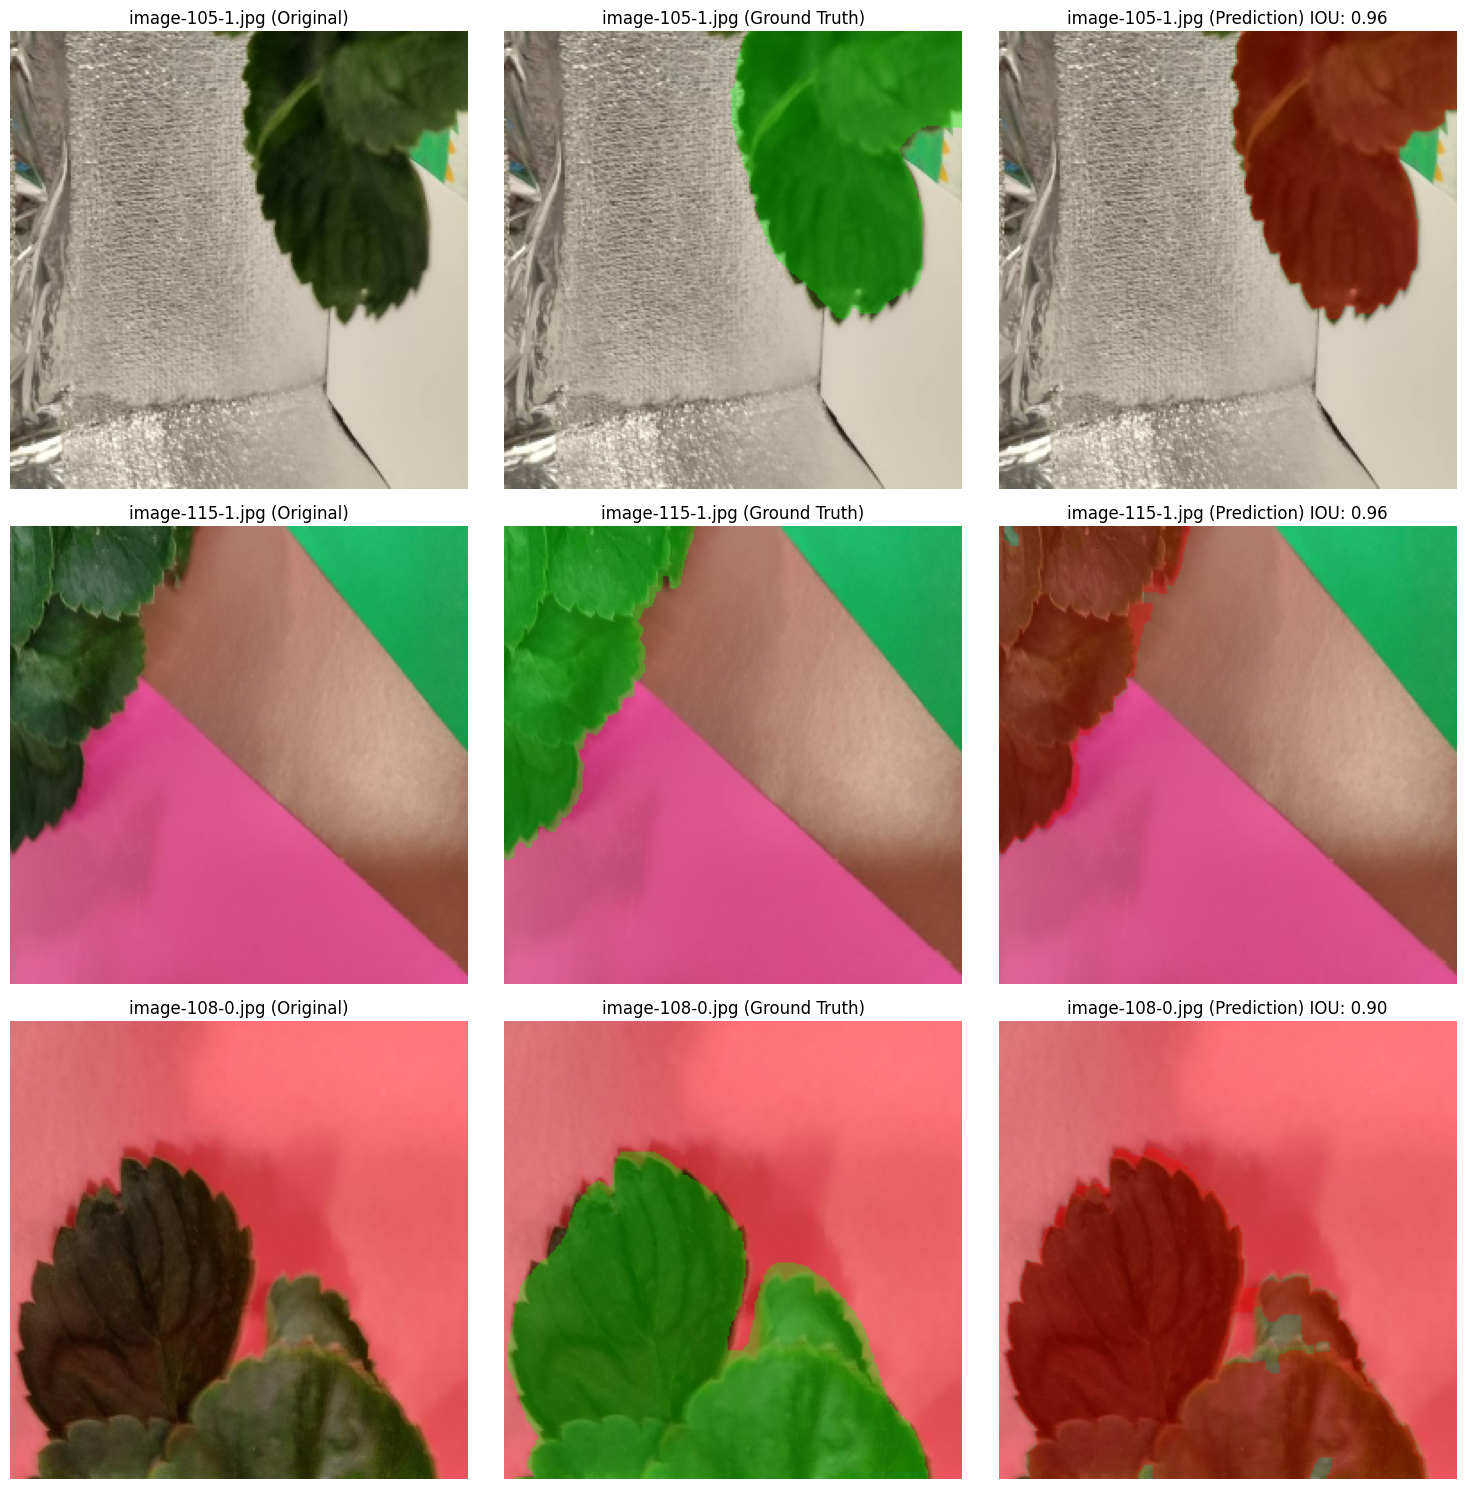

In [22]:
original_method_df = df[df['method'] == 'original'].sort_values(by='iou', ascending=False)

print('Top 3 Success Cases (Original Method):')
success_cases = original_method_df.head(3)
images_to_show = []
titles_to_show = []

for _, row in success_cases.iterrows():
    img_name = row['image']
    img_path, mask_path = next((p_img, p_mask) for p_img, p_mask in pairs if p_img.name == img_name)
    img = read_image(img_path)
    gt = read_mask(mask_path)
    _, _, pred = segment_method(img, kernel_size=(5, 5), thresh_type=cv2.THRESH_BINARY_INV, adaptive_thresh_block_size=None)

    images_to_show.extend([img, overlay_mask(img, gt, color=(0, 255, 0)), overlay_mask(img, pred, color=(255, 0, 0))])
    titles_to_show.extend([f'{img_name} (Original)', f'{img_name} (Ground Truth)', f'{img_name} (Prediction) IOU: {row["iou"]:.2f}'])

show_many(images_to_show, titles_to_show, cols=3, size=(15, 15))

Bottom 3 Failure Cases (Original Method):


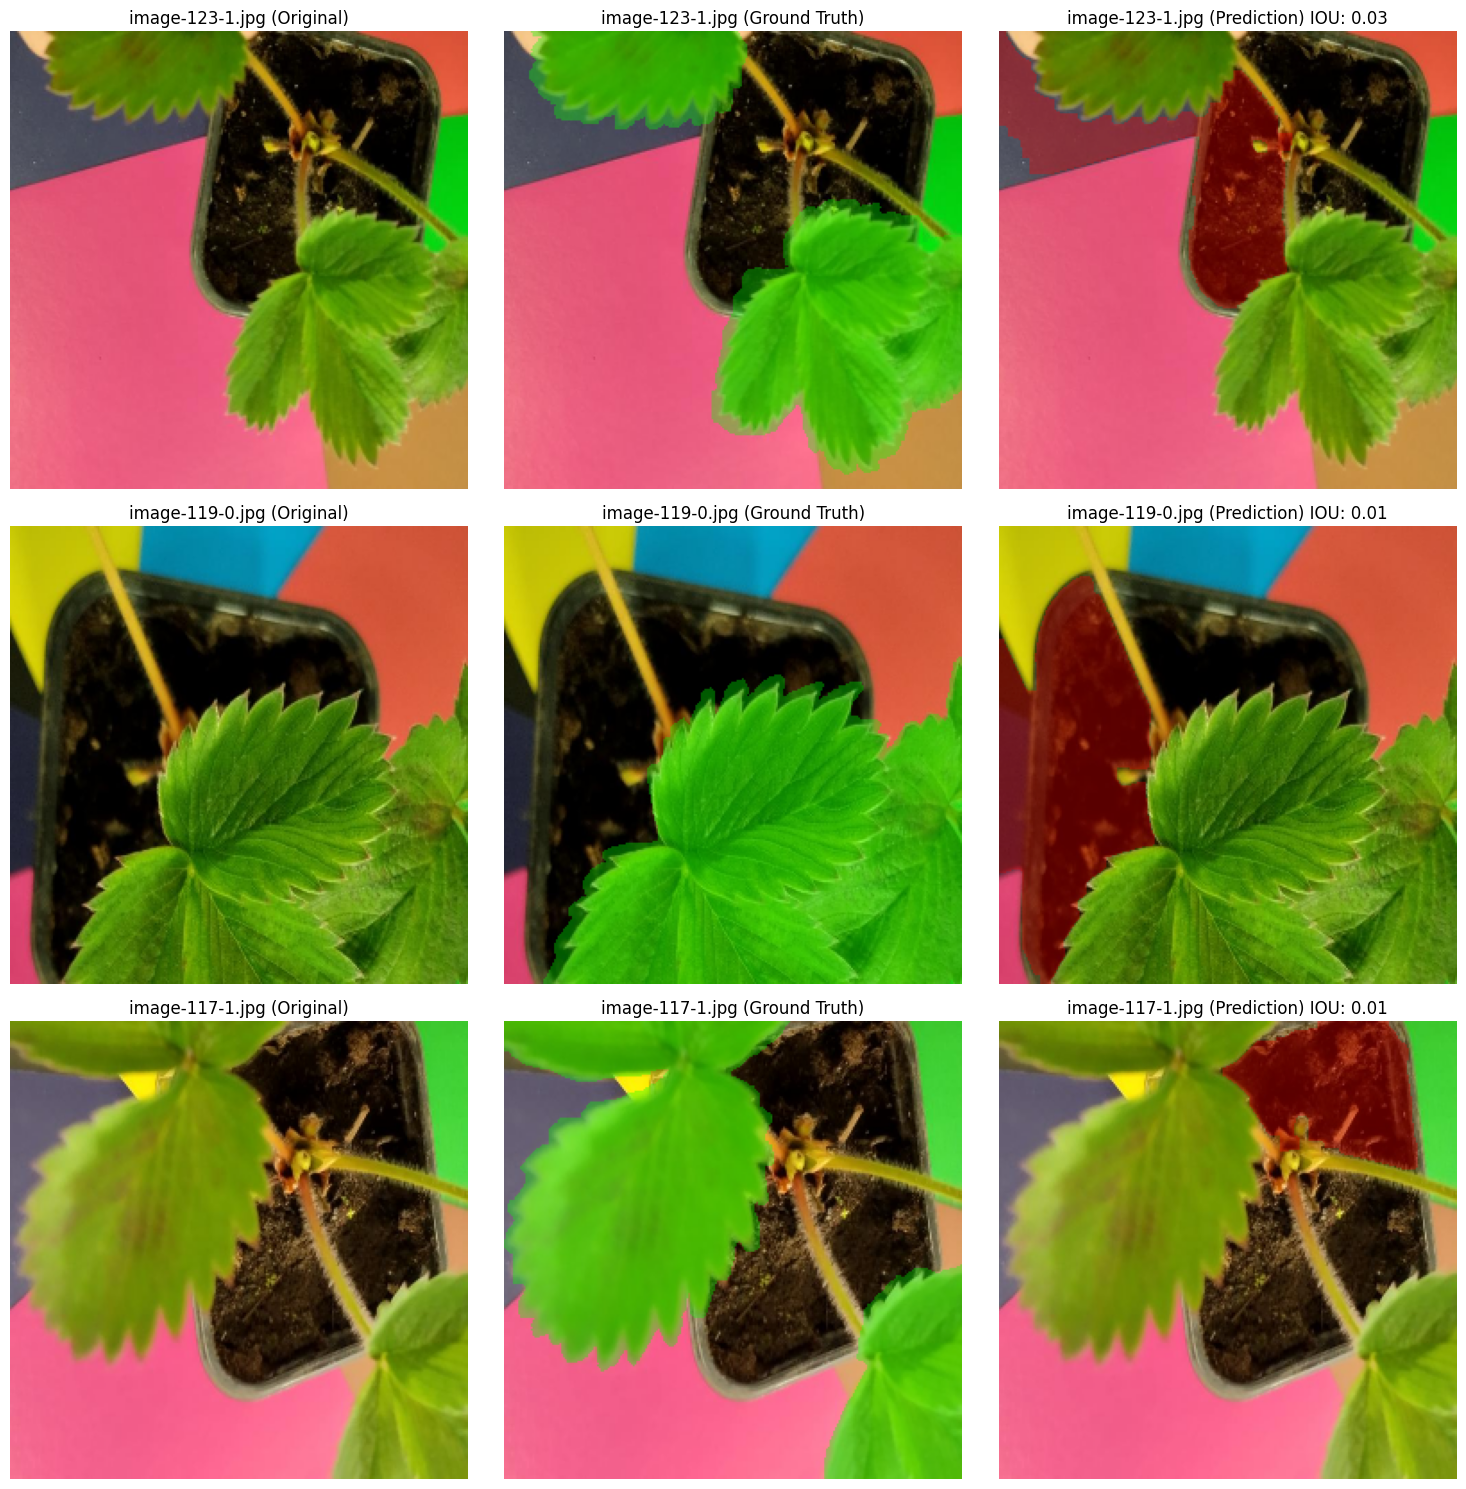

In [23]:
print('Bottom 3 Failure Cases (Original Method):')
failure_cases = original_method_df.tail(3)
images_to_show = []
titles_to_show = []

for _, row in failure_cases.iterrows():
    img_name = row['image']
    img_path, mask_path = next((p_img, p_mask) for p_img, p_mask in pairs if p_img.name == img_name)
    img = read_image(img_path)
    gt = read_mask(mask_path)
    _, _, pred = segment_method(img, kernel_size=(5, 5), thresh_type=cv2.THRESH_BINARY_INV, adaptive_thresh_block_size=None)

    images_to_show.extend([img, overlay_mask(img, gt, color=(0, 255, 0)), overlay_mask(img, pred, color=(255, 0, 0))])
    titles_to_show.extend([f'{img_name} (Original)', f'{img_name} (Ground Truth)', f'{img_name} (Prediction) IOU: {row["iou"]:.2f}'])

show_many(images_to_show, titles_to_show, cols=3, size=(15, 15))

In [17]:

RESULTS_DIR = DRIVE_PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df.to_csv(RESULTS_DIR / "simple_segmentation_results.csv", index=False)

print("Saved to:", RESULTS_DIR / "simple_segmentation_results.csv")

Saved to: /content/drive/MyDrive/simple_segmentation_training/results/simple_segmentation_results.csv


Top 3 Success Cases (Original Method):


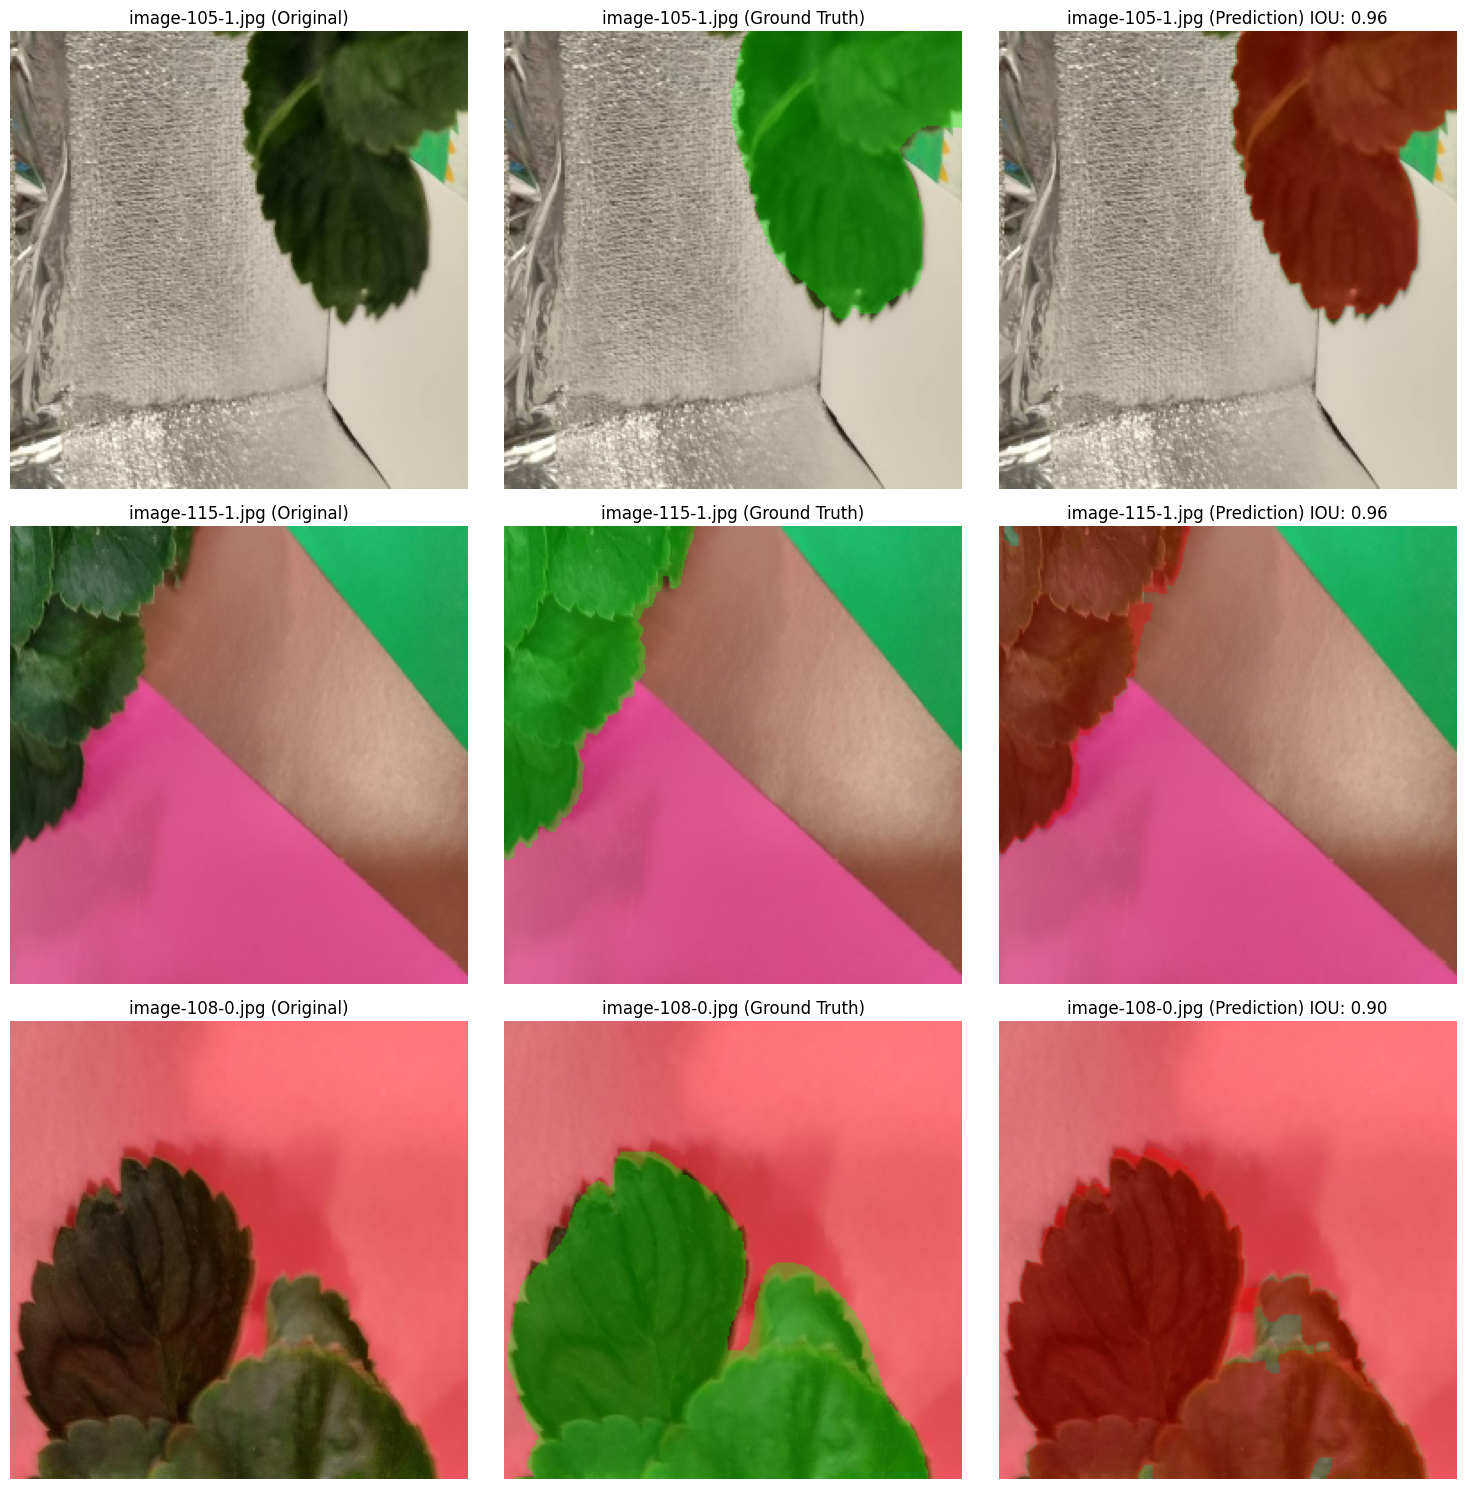

In [24]:
original_method_df = df[df['method'] == 'original'].sort_values(by='iou', ascending=False)

print('Top 3 Success Cases (Original Method):')
success_cases = original_method_df.head(3)
images_to_show = []
titles_to_show = []

for _, row in success_cases.iterrows():
    img_name = row['image']
    img_path, mask_path = next((p_img, p_mask) for p_img, p_mask in pairs if p_img.name == img_name)
    img = read_image(img_path)
    gt = read_mask(mask_path)
    _, _, pred = segment_method(img, kernel_size=(5, 5), thresh_type=cv2.THRESH_BINARY_INV, adaptive_thresh_block_size=None)

    images_to_show.extend([img, overlay_mask(img, gt, color=(0, 255, 0)), overlay_mask(img, pred, color=(255, 0, 0))])
    titles_to_show.extend([f'{img_name} (Original)', f'{img_name} (Ground Truth)', f'{img_name} (Prediction) IOU: {row["iou"]:.2f}'])

show_many(images_to_show, titles_to_show, cols=3, size=(15, 15))

Bottom 3 Failure Cases (Original Method):


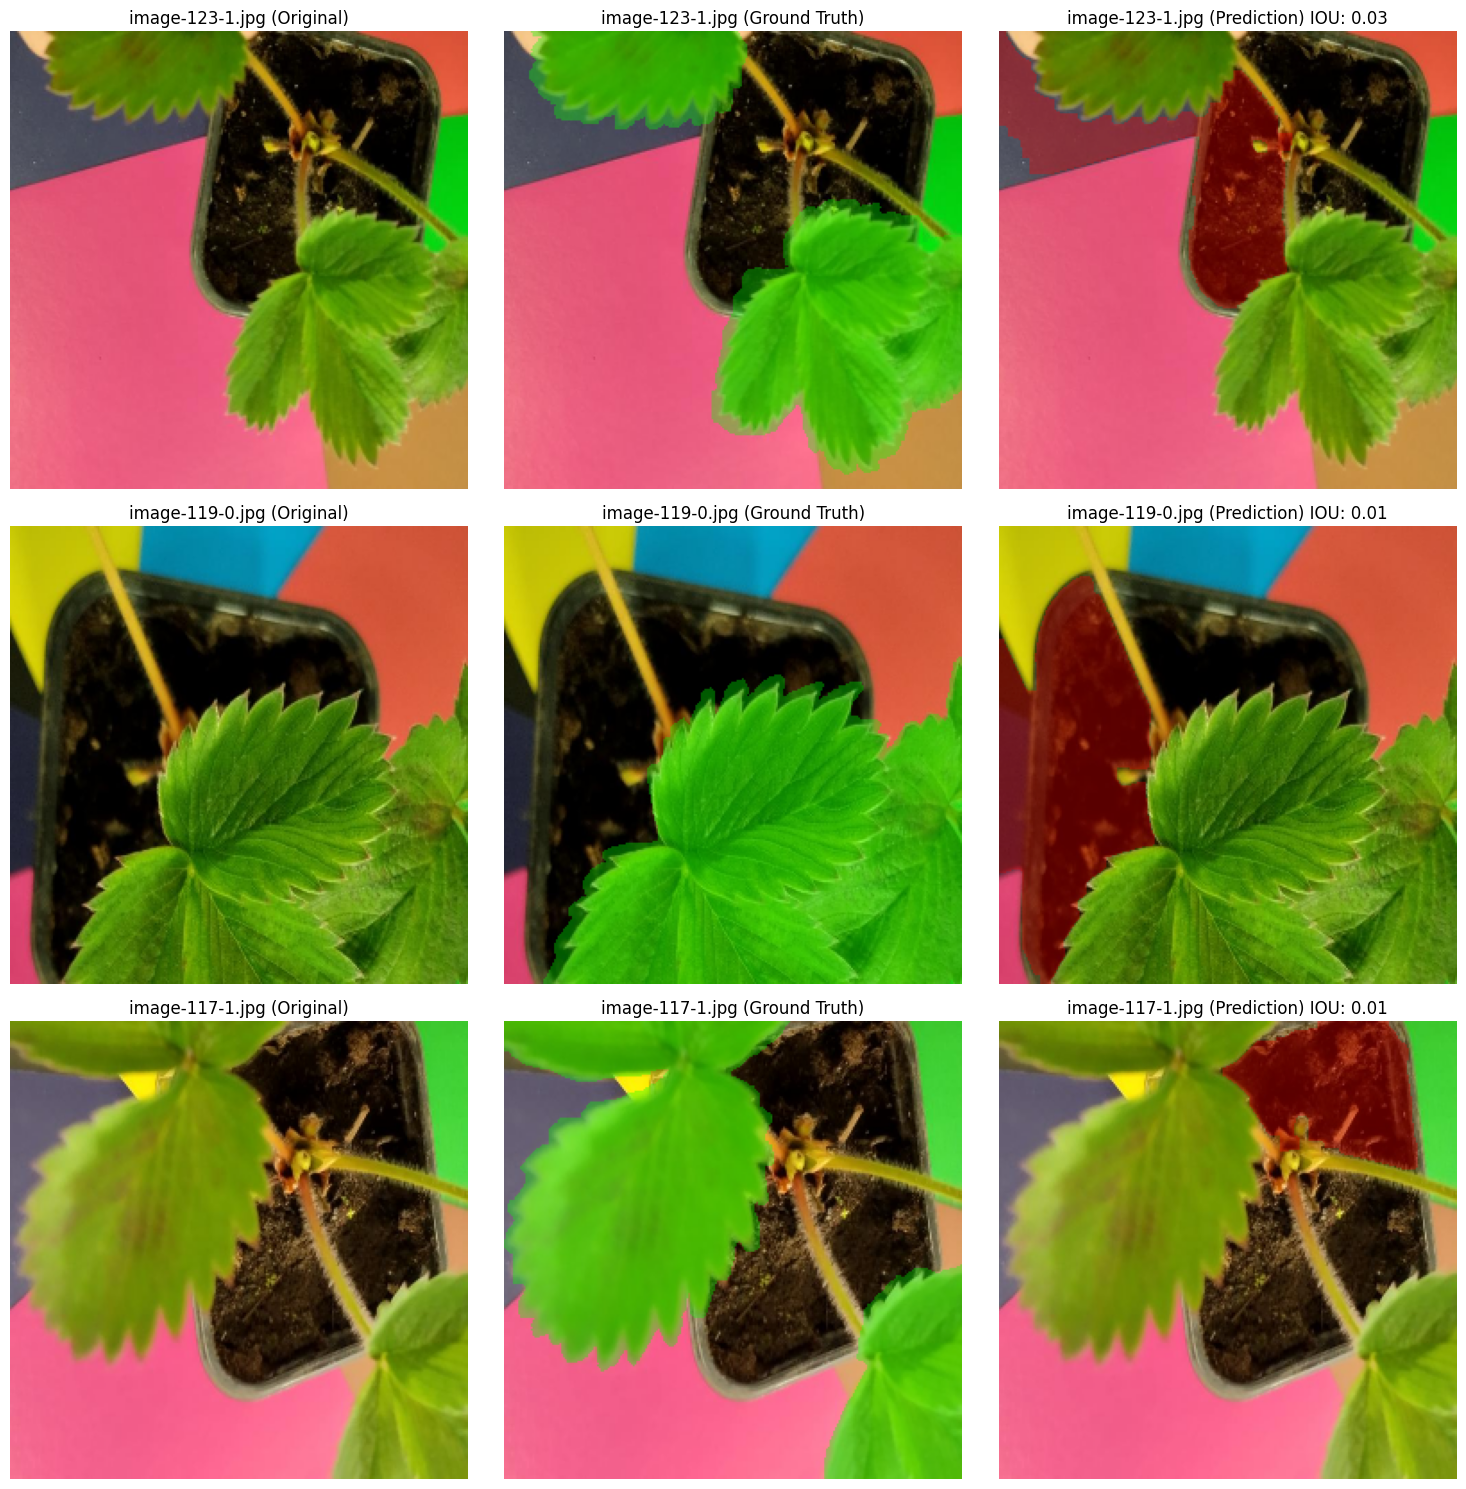

In [25]:
print('Bottom 3 Failure Cases (Original Method):')
failure_cases = original_method_df.tail(3)
images_to_show = []
titles_to_show = []

for _, row in failure_cases.iterrows():
    img_name = row['image']
    img_path, mask_path = next((p_img, p_mask) for p_img, p_mask in pairs if p_img.name == img_name)
    img = read_image(img_path)
    gt = read_mask(mask_path)
    _, _, pred = segment_method(img, kernel_size=(5, 5), thresh_type=cv2.THRESH_BINARY_INV, adaptive_thresh_block_size=None)

    images_to_show.extend([img, overlay_mask(img, gt, color=(0, 255, 0)), overlay_mask(img, pred, color=(255, 0, 0))])
    titles_to_show.extend([f'{img_name} (Original)', f'{img_name} (Ground Truth)', f'{img_name} (Prediction) IOU: {row["iou"]:.2f}'])

show_many(images_to_show, titles_to_show, cols=3, size=(15, 15))